In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import higher

In [2]:
def create_datasets(seq_len=5, n_samples=50, train_frac=0.8, seed=0):
    torch.manual_seed(seed)
    X = torch.randn(n_samples, seq_len, 1)
    y = X.sum(dim=1)
    
    train_size = int(n_samples * train_frac)
    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:], y[train_size:]
    
    return X_train, y_train, X_val, y_val


In [3]:
# --- Simple RNN ---
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=10, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)

In [8]:
# Data and model
X_train, y_train, X_val, y_val = create_datasets(n_samples=200, seed=5)
model = SimpleRNN()
criterion = nn.MSELoss()

# Parameters and optimizers
log_lambda = torch.tensor(-5.0, requires_grad=True)
model_optimizer = optim.SGD(model.parameters(), lr=0.01)
lambda_optimizer = optim.SGD([log_lambda], lr=0.1)

# Histories for plotting
l2_history = []
hypergrad_history = []
train_loss_history = []
val_loss_history = []

epochs = 200
for epoch in range(epochs):
    model.train()
    lambda_val = torch.exp(log_lambda)

    with higher.innerloop_ctx(model, model_optimizer, copy_initial_weights=False) as (fmodel, diffopt):
    # --- T1 step ---
        train_preds = fmodel(X_train)
        l2 = sum((p ** 2).sum() for p in fmodel.parameters())
        train_loss = criterion(train_preds, y_train) + lambda_val * l2
        diffopt.step(train_loss)

        # --- T2 step ---
        val_preds = fmodel(X_val)
        val_loss = criterion(val_preds, y_val)

        # Recompute train_loss for fresh graph after diffopt.step
        train_preds = fmodel(X_train)
        l2 = sum((p ** 2).sum() for p in fmodel.parameters())
        train_loss_updated = criterion(train_preds, y_train) + lambda_val * l2

        # Gradients wrt model params
        train_grads = torch.autograd.grad(train_loss_updated, fmodel.parameters(), create_graph=True)
        val_grads = torch.autograd.grad(val_loss, fmodel.parameters(), retain_graph=True)

        # Dot product and hypergrad
        dot = sum((v * t).sum() for v, t in zip(val_grads, train_grads))
        hypergrad = torch.autograd.grad(dot, log_lambda)[0]

    # Update log_lambda
    log_lambda.grad = hypergrad
    lambda_optimizer.step()
    lambda_optimizer.zero_grad()

    # Normal training step
    model_optimizer.zero_grad()
    outputs = model(X_train)
    l2_reg = sum(torch.sum(p**2) for p in model.parameters())
    train_loss = criterion(outputs, y_train) + lambda_val.detach() * l2_reg
    train_loss.backward()
    model_optimizer.step()

    # Save histories
    l2_history.append(lambda_val.item())
    hypergrad_history.append(hypergrad.item())
    train_loss_history.append(train_loss.item())
    val_loss_history.append(val_loss.item())

    print(f"Epoch {epoch+1}: train_loss={train_loss.item():.4f}, val_loss={val_loss.item():.4f}, lambda={lambda_val.item():.6f}")


Epoch 1: train_loss=4.6180, val_loss=2.4119, lambda=0.006738
Epoch 2: train_loss=4.6023, val_loss=2.4048, lambda=0.006738


Epoch 3: train_loss=4.5866, val_loss=2.3976, lambda=0.006739
Epoch 4: train_loss=4.5709, val_loss=2.3904, lambda=0.006740
Epoch 5: train_loss=4.5551, val_loss=2.3832, lambda=0.006740
Epoch 6: train_loss=4.5393, val_loss=2.3759, lambda=0.006741
Epoch 7: train_loss=4.5234, val_loss=2.3686, lambda=0.006742
Epoch 8: train_loss=4.5073, val_loss=2.3612, lambda=0.006743
Epoch 9: train_loss=4.4911, val_loss=2.3537, lambda=0.006745
Epoch 10: train_loss=4.4747, val_loss=2.3461, lambda=0.006746
Epoch 11: train_loss=4.4580, val_loss=2.3384, lambda=0.006748
Epoch 12: train_loss=4.4412, val_loss=2.3306, lambda=0.006749
Epoch 13: train_loss=4.4240, val_loss=2.3227, lambda=0.006751
Epoch 14: train_loss=4.4066, val_loss=2.3146, lambda=0.006753
Epoch 15: train_loss=4.3888, val_loss=2.3063, lambda=0.006755
Epoch 16: train_loss=4.3706, val_loss=2.2978, lambda=0.006757
Epoch 17: train_loss=4.3521, val_loss=2.2891, lambda=0.006760
Epoch 18: train_loss=4.3331, val_loss=2.2802, lambda=0.006762
Epoch 19: train

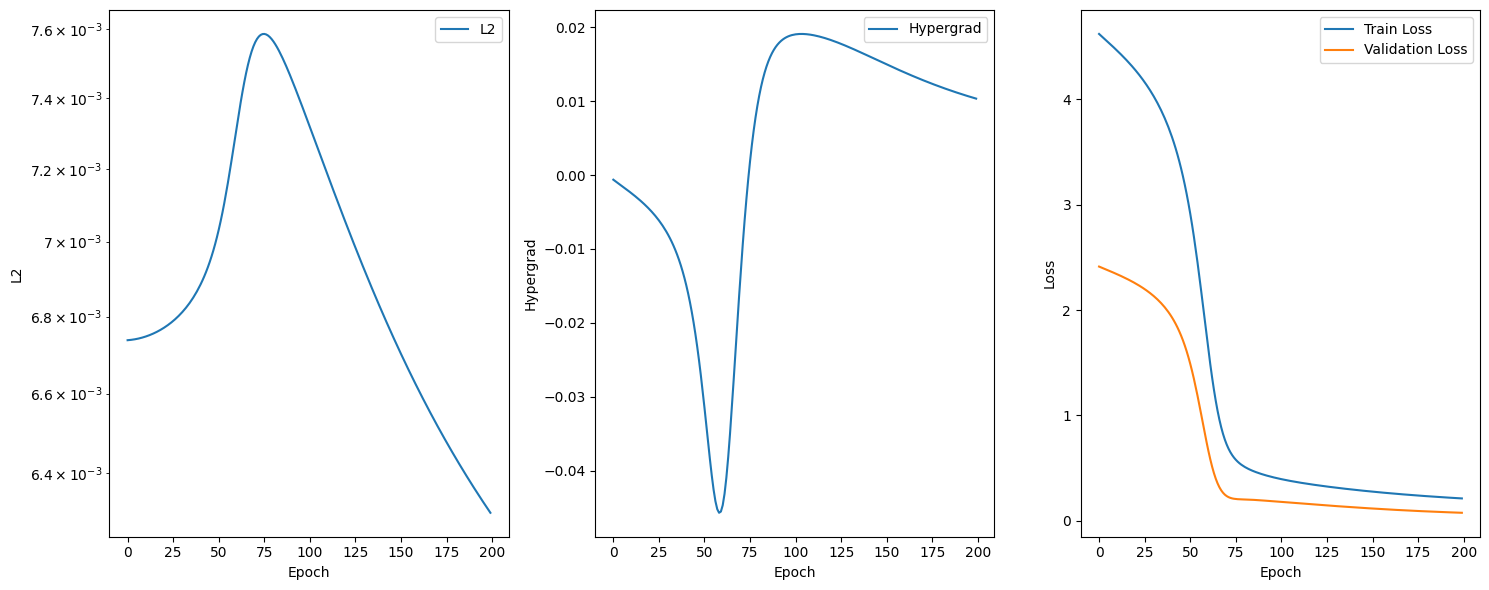

In [9]:
plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
plt.plot(l2_history, label='L2')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('L2')
plt.legend()

plt.subplot(1,3,2)
plt.plot(hypergrad_history, label='Hypergrad')
plt.xlabel('Epoch')
plt.ylabel('Hypergrad')
plt.legend()

plt.subplot(1,3,3)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()